# L6d Lab: Compare Jacobi, Gauss–Seidel, and SOR

> **Learning objectives**
>
> - Solve the same diagonally dominant system with three stationary methods.
> - Compare iteration counts without confusing speed with correctness.
> - Validate each result against the direct solve and the residual contract.
> - Explore how the SOR relaxation parameter changes convergence.


## Setup


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


In [2]:
A = [4.0 -1.0 0.0; -1.0 4.0 -1.0; 0.0 -1.0 3.0]
b = [15.0, 10.0, 10.0]
direct = A \ b

jacobi = stationary_solve(A, b; method = :jacobi)
gauss_seidel = stationary_solve(A, b; method = :gauss_seidel)
sor = stationary_solve(A, b; method = :sor, omega = 1.1)

comparison = DataFrame(
    method = ["Jacobi", "Gauss–Seidel", "SOR (ω=1.1)"],
    iterations = [jacobi.iterations, gauss_seidel.iterations, sor.iterations],
    final_residual = [last(jacobi.residuals), last(gauss_seidel.residuals), last(sor.residuals)],
    error_to_direct = [norm(jacobi.solution-direct), norm(gauss_seidel.solution-direct), norm(sor.solution-direct)],
)
pretty_table(comparison)


┌──────────────┬────────────┬────────────────┬─────────────────┐
│       method │ iterations │ final_residual │ error_to_direct │
│       String │      Int64 │        Float64 │         Float64 │
├──────────────┼────────────┼────────────────┼─────────────────┤
│       Jacobi │         28 │    3.91066e-11 │     1.71581e-11 │
│ Gauss–Seidel │         15 │    1.89843e-11 │     6.18809e-12 │
│  SOR (ω=1.1) │         13 │    1.82363e-12 │     7.89858e-13 │
└──────────────┴────────────┴────────────────┴─────────────────┘


In [3]:
@test all(result.converged for result in (jacobi, gauss_seidel, sor))
@test all(result.solution ≈ direct for result in (jacobi, gauss_seidel, sor))
@test sor.iterations < jacobi.iterations
:iterative_solvers_verified


:iterative_solvers_verified

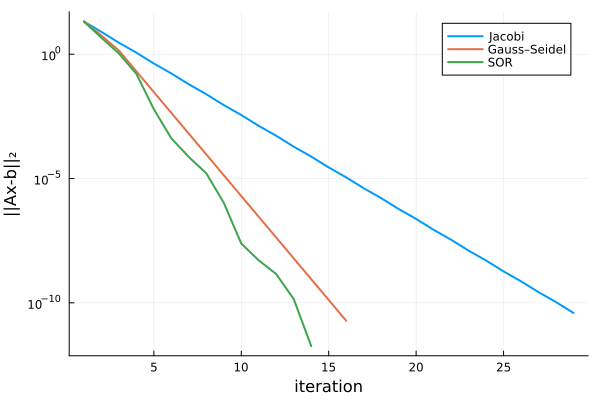

In [4]:
plot(jacobi.residuals; yscale = :log10, lw = 2, label = "Jacobi",
    xlabel = "iteration", ylabel = "||Ax-b||₂")
plot!(gauss_seidel.residuals; lw = 2, label = "Gauss–Seidel")
plot!(sor.residuals; lw = 2, label = "SOR")


## Summary

All three methods reach the same verified solution. On this system, reuse of current information reduces the iteration count, and mild over-relaxation helps further. That ordering is problem-dependent, so the residual history—not the method name—is the defensible evidence.
